# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

#  Baseline Run (Original Assignment Spec — 100 Epochs)
This section runs the **original, unmodified assignment requirements** 

In [ ]:
corpus_base = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus_base)

deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences


In [ ]:
tokenizer_base = Tokenizer()
tokenizer_base.fit_on_texts([corpus_base])
total_words_base = len(tokenizer_base.word_index) + 1

input_sequences_base = []
for line in corpus_base.split('\n'):
    token_list = tokenizer_base.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_base.append(token_list[:i+1])

max_len_base = max(len(seq) for seq in input_sequences_base)
input_sequences_base = pad_sequences(input_sequences_base, maxlen=max_len_base, padding='pre')

X_base = input_sequences_base[:, :-1]
y_base = input_sequences_base[:, -1]
print("X_base shape:", X_base.shape)
print("y_base shape:", y_base.shape)

X_base shape: (35, 7)
y_base shape: (35,)


In [4]:
rnn_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    SimpleRNN(64),
    Dense(total_words_base, activation='softmax')
])

lstm_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    LSTM(64),
    Dense(total_words_base, activation='softmax')
])

gru_model_base = Sequential([
    Embedding(total_words_base, 32, input_length=max_len_base-1),
    GRU(64),
    Dense(total_words_base, activation='softmax')
])

for m in (rnn_model_base, lstm_model_base, gru_model_base):
    m.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

c:\Users\LOQ\.conda\envs\ml_env\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [5]:
rnn_history_base = rnn_model_base.fit(X_base, y_base, epochs=100, verbose=0)
print("Baseline Vanilla RNN training completed")

lstm_history_base = lstm_model_base.fit(X_base, y_base, epochs=100, verbose=0)
print("Baseline LSTM training completed")

gru_history_base = gru_model_base.fit(X_base, y_base, epochs=100, verbose=0)
print("Baseline GRU training completed")

Baseline Vanilla RNN training completed
Baseline LSTM training completed
Baseline GRU training completed


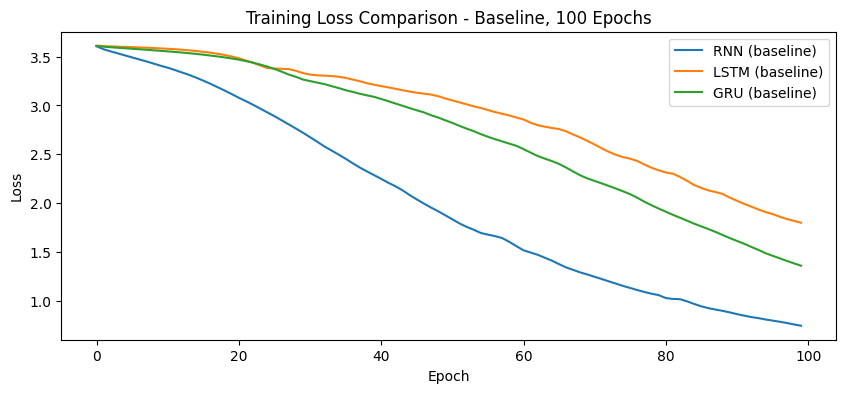

In [6]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history_base.history['loss'], label='RNN (baseline)')
plt.plot(lstm_history_base.history['loss'], label='LSTM (baseline)')
plt.plot(gru_history_base.history['loss'], label='GRU (baseline)')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison - Baseline, 100 Epochs")
plt.legend()
plt.show()

In [7]:
def generate_text_base(model, tokenizer_obj, max_len_val, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer_obj.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len_val-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]
        output_word = ""
        for word, index in tokenizer_obj.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

print("RNN :", generate_text_base(rnn_model_base, tokenizer_base, max_len_base, "deep learning", 5))
print("LSTM:", generate_text_base(lstm_model_base, tokenizer_base, max_len_base, "deep learning", 5))
print("GRU :", generate_text_base(gru_model_base, tokenizer_base, max_len_base, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning can artificial meaningful meaningful
GRU : deep learning is faster and simpler than


#  Completed Given Tasks (Custom Corpus, 128 dim/units, 200 Epochs, 10 words)
Everything below this point is the **completed student-tasks version**: custom paragraph corpus, larger embedding/hidden units, 200 epochs, and 10-word generation.

In [8]:
corpus = '''
Shubham Dogra is in the celebal technology where he  made several contribution in the 
field of machine learning and deep learning. 
He is a great student and a good human being.
Shubham dogra is in Dit university where he is pursuing his B.Tech in computer science and engineering.
Shubham Dogra is currently working on text generation using RNN, LSTM and GRU.
'''
print(corpus)


Shubham Dogra is in the celebal technology where he  made several contribution in the 
field of machine learning and deep learning. 
He is a great student and a good human being.
Shubham dogra is in Dit university where he is pursuing his B.Tech in computer science and engineering.
Shubham Dogra is currently working on text generation using RNN, LSTM and GRU.



#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [9]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 43
X shape: (57, 17)
y shape: (57,)


#  Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [10]:
rnn_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


#  Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [11]:
lstm_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


#  Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [12]:
gru_model = Sequential([
    Embedding(total_words, 128, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


##  Compare Training Loss

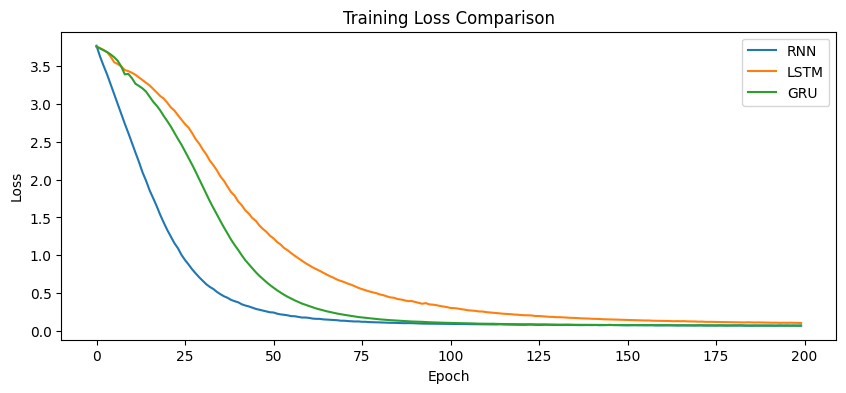

In [13]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

#  Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [14]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

##  Generate Text Samples

In [15]:
print("RNN :", generate_text(rnn_model, "Shubham Dogra", 10))
print("LSTM:", generate_text(lstm_model, "Shubham Dogra", 10))
print("GRU :", generate_text(gru_model, "Shubham Dogra", 10))

RNN : Shubham Dogra is in dit university where he is pursuing his b
LSTM: Shubham Dogra is in the celebal technology where he made several contribution
GRU : Shubham Dogra is in dit university where he is pursuing his b


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**